# Проект: Исследование стартапов

## Введение

Финансовая компания, которая предоставляет льготные займы стартапам, хочет войти на инвестиционный рынок с прицелом на покупку, развитие и последующую перепродажу перспективных стартапов. Для разработки модели бизнеса нужна информация. Чтобы выработать общее понимание, какие данные могут быть полезны

**Цель:** Подготовить датасет и проверить, что данные в нём соответствуют здравому смыслу, а также ответить на вопросы заказчика как о предобработке, так и о значении данных для бизнеса.

**Задачи:**

1. Загрузить данные и познакомиться с их содержимым.

2. Провести предобработку данных.

3. Провести исследовательский анализ данных:  

    3.1 **Объединение данных**. Объединить данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев.  
    
    3.2 **Анализ выбросов.** Оценить, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.  
    
    3.3 **Куплены забесплатно?** Исследовать компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования. Рассчитать аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и указать, каким процентилям границы соответствуют.  
    
    3.4 **Цены стартапов по категориям.** Среди категорий стартапов выделите категории стартапов, характеризующиеся:  
     * Типично высокими ценами;  
     * Наибольшим разбросом цен за стартап.   
     
   3.5 **Сколько раундов продержится стартап перед покупкой.** Проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Найти типичное значение количества раундов для каждого возможного статуса стартапа. Добавить визуализацию результатов  
   
   
4. Сформулировать выводы по проведённому анализу.

## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv

### Описание данных:

#### Описание датасета `acquisition`  
Содержит информацию о покупках одними компаниями других компаний:  
`id` — идентификатор покупки.  
`acquiring_company_id` — идентификатор покупающей компании.  
`acquired_company_id` — идентификатор покупаемой компании.  
`term_code` — варианты расчёта.  
`price_amount` — сумма сделки.  
`acquired_at` — дата сделки.  
#### Описание датасета `company_and_rounds`
Содержит информацию о компаниях и раундах финансирования:  
`company ID`— идентификатор компании.  
`name` — название компании.  
`category code` — категория области деятельности компании.  
`status` — статус компании.  
`founded at` — дата инвестирования.  
`closed at` — дата закрытия компании.  
`domain` — официальный сайт компании.  
`network username` — ник компании в сети.  
`country code` — код страны компании.  
`investment rounds` — число инвестиционных раундов.  
`funding rounds` — число раундов финансирования.  
`funding total` — сумма финансирования.  
`milestones` — вехи финансирования.  
`funding round id` — идентификатор этапа финансирования.  
`company id` — идентификатор компании.  
`funded at` — дата финансирования.  
`funding round type` — тип финансирования.  
`raised amount` — сумма финансирования.  
`pre money valuation` — предварительная денежная оценка.  
`participants` — число участников.  
`is first round` — является ли раунд первым.  
`is last round` — является раунд последним.  
#### Описание датасета  `education`  
Содержит информацию об образовании сотрудника:  
`id` — идентификатор записи об образовании.  
`person_id` — идентификатор работника.  
`instituition` — название учебного заведения.  
`graduated_at` — дата получения образования.  
#### Описание датасета  `people`  
Содержит информацию о сотрудниках:  
`id` — идентификатор сотрудника.  
`first_name` — имя сотрудника.  
`last_name` — фамилия сотрудника.  
`company_id` — идентификатор компании.  
`network_username` — ник в социальных сетях.  
#### Описание датасета `degrees`  
Содержит информацию о типе образования сотрудника:  
`id` — идентификатор записи.  
`object_id` — идентификатор сотрудника.  
`degree_type` — тип образования.  
`subject` — специальность.  


### Загрузка данных

Начнём с загрузки библиотек и датасетов `acquisition`, `company_and_rounds`, `education`, `people` и `degrees`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `acquisition_df`, `company_and_rounds_df`, `education_df`, `people_df`, `degrees_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix


In [2]:
acquisition_df = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
company_and_rounds_df = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
education_df = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
people_df = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')
degrees_df = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')

### Вывод общей информации, исправление названия столбцов

In [3]:
acquisition_df.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [4]:
acquisition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


Датасет `acquisition.csv` состоит из 6 столбцов и 9407 строк.  
После первичного анализа можно сделать следующие выводы:  
Названия столбцов в едином стиле(snake_case)  
Большинство данных принадлежат к типу `int64`  
Пропуски содержатся в столбцах `term_code` и `acquired_at`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.  

Перейдем к датасету `company_and_rounds.csv`

In [5]:
company_and_rounds_df.head()

,company ID,name,category code,status,founded at,closed at,domain,network username,country code,investment rounds,...,milestones,funding round id,company id,funded at,funding round type,raised amount,pre money valuation,participants,is first round,is last round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
company_and_rounds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   company  ID            217472 non-null  float64
 1   name                   217472 non-null  object 
 2   category  code         143886 non-null  object 
 3   status                 217472 non-null  object 
 4   founded  at            109956 non-null  object 
 5   closed  at             3449 non-null    object 
 6   domain                 147159 non-null  object 
 7   network  username      95534 non-null   object 
 8   country  code          108607 non-null  object 
 9   investment  rounds     217472 non-null  float64
 10  funding  rounds        217472 non-null  float64
 11  funding  total         217472 non-null  float64
 12  milestones             217472 non-null  float64
 13  funding  round  id     52928 non-null   float64
 14  company  id            52928 non-nul

Датасет `company_and_rounds.csv` состоит из 22 столбцов и 217774 строк.
После первичного анализа можно сделать следующие выводы:  
Названия столбцов не преведены к единому стилю    
Данные в формате `float64` и `object`   
Пропуски содержатся во всех столбцах
Датасет имеет 2 столбца с именем company ID

Сразу приведем названия столбцов к единому стилю

In [7]:
company_and_rounds_df = company_and_rounds_df.rename(columns={'company  ID':'company_id_1',
                                                              'category  code':'category_code',
                                                              'founded  at':'founded_at',
                                                              'closed  at':'closed_at',
                                                              'network  username':'network_username',
                                                              'country  code':'country_code',
                                                              'investment  rounds':'investment_rounds',
                                                              'funding  rounds':'funding_rounds',
                                                              'funding  total':'funding_total',
                                                              'funding  round  id':'funding_round_id',
                                                              'company  id':'company_id_2',
                                                              'funded  at':'funded_at',
                                                              'funding  round  type':'funding_round_type',
                                                              'raised  amount':'raised_amount',
                                                              'pre  money  valuation':'pre_money_valuation',
                                                              'is  first  round':'is_first_round',
                                                              'is  last  round':'is_last_round'})
company_and_rounds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id_1         217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  company_id_2         52928 non-null   float64
 15  funded_at        

Перейдем к датасету `education.csv`

In [8]:
education_df.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


In [9]:
education_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


Датасет `education.csv` состоит из 4 столбцов и 109610 строк.  
После первичного анализа можно сделать следующие выводы:  
Названия столбцов в едином стиле(snake_case)   
Данные в формате `int64` и `object`  
Пропуски содержатся в столбцах `instituition` и `graduated_at`  

Перейдем к датасету `people.csv`

In [10]:
people_df.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [11]:
people_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


Датасет `people.csv` состоит из 5 столбцов и 226709 строк.
После первичного анализа можно сделать следующие выводы:
Названия столбцов в едином стиле(snake_case)  
Данные в формате `int64`, `object` и `float64`  
Пропуски содержатся в столбцах `first_name`, `last_name`, `company_id` и `network_username`

Перейдем к последнему датасету degrees.csv

In [12]:
degrees_df.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [13]:
degrees_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


Датасет `degrees.csv` состоит из 4 столбцов и 109610 строк.
После первичного анализа можно сделать следующие выводы:
Названия столбцов в едином стиле(snake_case)  
Данные в формате `int64` и `object` 
Пропуски содержатся в столбцах `first_name`, `last_name`, `degree_type` и `subject`

### Смена типов и анализ пропусков

#### Смена типов
В датафрейме `acquisition_df` заменим тип данных `object` на `datetime64` в столбце `acquired_at`

In [14]:
acquisition_df['acquired_at'] = acquisition_df['acquired_at'].astype('datetime64')
acquisition_df['acquired_at'].dtype

dtype('<M8[ns]')

Аналогичным образом в датафрейме `company_and_rounds_df` заменим тип данных `object` на `datetime64` в столбцах `founded_at`, `closed_at` и `funded_at` 

In [15]:
company_and_rounds_df[['founded_at','closed_at','funded_at']] = company_and_rounds_df[['founded_at','closed_at','funded_at']].astype('datetime64')
company_and_rounds_df[['founded_at','closed_at','funded_at']].dtypes

founded_at    datetime64[ns]
closed_at     datetime64[ns]
funded_at     datetime64[ns]
dtype: object

Аналогичным образом в датафрейме `education_df` заменим тип данных `object` на `datetime64` в столбце `graduated_at`

In [16]:
education_df['graduated_at'] = education_df['graduated_at'].astype('datetime64')
education_df['graduated_at'].dtype
education_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB


#### Анализ пропусков

In [17]:
# число пропусков
missing_count = acquisition_df.isna().sum()

# доля пропусков
missing_percent = acquisition_df.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

                      missing_count  missing_percent
id                                0         0.000000
acquiring_company_id              0         0.000000
acquired_company_id               0         0.000000
term_code                      7576         0.805358
price_amount                      0         0.000000
acquired_at                      29         0.003083


`acquired_at` содержит ~ 0.3% пропусков   
`term_code` содержит ~ 80% пропусков   

Возможные причины пропусков в `term_code`:   

Работа с **историческими данными:**  
В старых сделках часто меньше информации, чем в новых. Возможно, `term_code` чаще указывают только в последние годы. Чтобы это проверить можно проанализировать поля `acquired_at` и `term_code` в строках с пропусками.

Перейдем к `company_and_rounds`

In [18]:
# число пропусков
missing_count = company_and_rounds_df.isna().sum()

# доля пропусков
missing_percent = company_and_rounds_df.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

                     missing_count  missing_percent
company_id_1                   302         0.001387
name                           302         0.001387
category_code                73888         0.339288
status                         302         0.001387
founded_at                  107818         0.495091
closed_at                   214325         0.984162
domain                       70615         0.324258
network_username            122240         0.561316
country_code                109167         0.501286
investment_rounds              302         0.001387
funding_rounds                 302         0.001387
funding_total                  302         0.001387
milestones                     302         0.001387
funding_round_id            164846         0.756959
company_id_2                164846         0.756959
funded_at                   165094         0.758098
funding_round_type          164846         0.756959
raised_amount               164846         0.756959
pre_money_va

Так как все столбцы содержат пропуски, акцентируем внимание только на наиболее высоких значениях: 

| Столбец                                | Пропуски | Объяснение                                                                                        |
| -------------------------------------- | -------- | ------------------------------------------------------------------------------------------------- |
| `category_code`                        | \~33%    | Не у всех компаний указана категория (старые данные, неполная информация в источниках)           |
| `founded_at`                           | \~49%    | Для многих компаний нет точной даты основания |
| `closed_at`                            | \~98%    | Большинство компаний продолжают работать, поэтому дата закрытия отсутствует                      |
| `domain`                               | \~32%    | У части компаний нет собственного сайта или данные не были собраны                               |
| `network_username`                     | \~56%    | Не у всех организаций есть профили в соцсетях/сетевых сервисах                                   |
| `country_code`                         | \~50%    | Данные о стране не всегда доступны          |
| `funding_round_id`                     | \~75%    | Заполняется только для компаний, участвующих в раундах финансирования                            |
| `company_id_2`                         | \~75%    | Аналогично, связано с данными по инвестиционным сделкам (только для компаний с инвестициями)     |
| `funded_at`, `funding_round_type`      | \~75%    | Заполняется только при наличии информации о раунде финансирования                                |
| `raised_amount`, `pre_money_valuation` | \~75%    | Финансовые данные часто не раскрываются публично или частично скрыты                             |
| `participants`                         | \~75%    | Количество участников раунда указывается не всегда, особенно в частных сделках                   |
| `is_first_round`                       | \~75%    | Эти признаки имеют смысл только при наличии данных о финансировании                              |
| `is_last_round`                        | \~75%    | Аналогично — заполняется только для компаний с историей инвестиций                               |

* Очень высокая доля пропусков связана с инвестиционными атрибутами (`funding_round_id`, `raised_amount`, `participants` и т. д.) т. к. не все компании проходят через раунды финансирования.

* `closed_at` почти всегда пустой, так как большинство компаний не закрылись.

* Умеренные пропуски (`category_code`, `domain`, `country_code`, `founded_at`) можно объяснить неполнотой или отсутствием публичной информации.

Перейдем к `education`

In [19]:
# число пропусков
missing_count = education_df.isna().sum()

# доля пропусков
missing_percent = education_df.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

              missing_count  missing_percent
id                        0         0.000000
person_id                 0         0.000000
instituition             55         0.000502
graduated_at          51556         0.470359


`graduated_at` содержит ~ 47% пропусков.  
Это можно объяснить тем, что работник не получал образование или находится в процессе обучения

Перейдем к `people`

In [20]:
# число пропусков
missing_count = people_df.isna().sum()

# доля пропусков
missing_percent = people_df.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

                  missing_count  missing_percent
id                            0         0.000000
first_name                    5         0.000022
last_name                     1         0.000004
company_id               192094         0.847315
network_username         187842         0.828560


`company_id` содержит ~85% пропусков  
Возможные причины:  
* Человек добавлен как пользователь платформы, но не ассоциирован с организацией;  
* Сотрудник мог быть добавлен в систему вручную, но без связи с компанией;  

`network_username` содержит ~83% пропусков  
Возможные причины:  
* У сотрудников могли не собираться социальные аккаунты, или сотрудники не имеют аккаунтов в социальных сетях
* Для многих записей эти данные не публиковались или были конфиденциальны.  
  

Перейдем к `degrees`

In [21]:
# число пропусков
missing_count = degrees_df.isna().sum()

# доля пропусков
missing_percent = degrees_df.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

             missing_count  missing_percent
id                       0         0.000000
object_id                0         0.000000
degree_type          11218         0.102345
subject              28312         0.258298


`degree_type` содержит ~10% пропусков  
Возможные причины: 
* Некоторые сотрудники указывали только специальность, без степени;
* Для курсов/сертификатов могло не быть формального указания уровня.

`subject` содержит ~26% пропусков  
Возможные причины:  
* Некоторые сотрудники указывали только степень, без специальности;
* Часть данных могла быть утеряна или не загружена.

## Шаг 2. Предобработка данных, предварительное исследование

### 2.1. Раунды финансирования по годам

**Задача:**   
1. Составить сводную таблицу по годам, в которой на основании столбца `raised_amount` для каждого года указан:

    * типичный размер средств, выделяемый в рамках одного раунда;
    * общее количество раундов финансирования за этот год.
    * Оставьте в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования.

2. Построить график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

3. Ответить на вопросы:

    * В каком году типичный размер собранных в рамках одного раунда средств был максимален?
    * Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

#### Составить сводную таблицу по годам

In [22]:

company_and_rounds_df['year'] = pd.to_datetime(company_and_rounds_df['funded_at']).dt.year
pivot_company_and_rounds = pd.pivot_table(company_and_rounds_df,
                                          index='year', 
                                          values='raised_amount',
                                          aggfunc={'raised_amount': ['median', 'count']})
filtered_pivot_company_and_rounds = pivot_company_and_rounds[pivot_company_and_rounds['count'] > 50]
print(filtered_pivot_company_and_rounds)

        count     median
year                    
1999.0     76  2000000.0
2000.0    125  4200000.0
2001.0     96  3000000.0
2002.0    116  4200000.0
2003.0    159  3000000.0
2004.0    291  5000000.0
2005.0   1633  5500000.0
2006.0   2436  5000000.0
2007.0   3279  3973320.0
2008.0   3774  3110000.0
2009.0   4151  2000000.0
2010.0   6221  1602500.0
2011.0   9204  1200000.0
2012.0   9970  1000000.0
2013.0  11072  1200000.0


#### Построить график

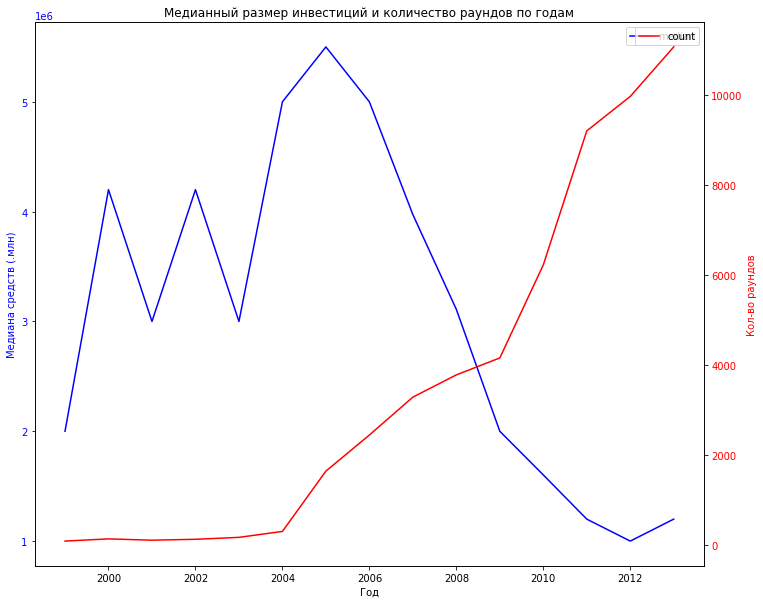

In [23]:
filtered_pivot_company_and_rounds = filtered_pivot_company_and_rounds.reset_index()

fig, ax1 = plt.subplots(figsize=(12,10))

ax1 = filtered_pivot_company_and_rounds.plot(x='year', y='median', color='blue', label='median', ax=ax1)
ax1.set_xlabel('Год')
ax1.set_ylabel('Медиана средств (.млн)', color='blue')
ax1.tick_params(axis='y', labelcolor="blue")

ax2 = ax1.twinx()
ax2 = filtered_pivot_company_and_rounds.plot(x='year', y='count', color='red', label='count', ax=ax2)
ax2.set_ylabel('Кол-во раундов' ,color = 'red')
ax2.tick_params(axis='y', labelcolor="red")



plt.title("Медианный размер инвестиций и количество раундов по годам")
plt.show()

#### Ответить на вопросы

В 2005 году наблюдался максимальный размер средств собранных рамках одного раунда.  
В 2013 году наблюдалась тенденция роста по количеству раундов и выделяемых в рамках каждого раунда средств

### 2.2. Люди и их образование

**Задача:**   
1. Оценить, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделить все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп. Обосновать выбранные границы групп.
2. Оценить, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

#### Оценить, насколько информация об образовании сотрудников полна

Анализ полноты данных датасетов `people.csv` и `education.csv` был проведен чуть выше. Продублирую результат:  
**`education.csv`** :  
`graduated_at` содержит ~ 47% пропусков.  
Это можно объяснить тем, что работник не получал образование или находится в процессе обучения

**`people.csv`** :  
`company_id` содержит ~85% пропусков  
Возможные причины:  
* Человек добавлен как пользователь платформы, но не ассоциирован с организацией;  
* Сотрудник мог быть добавлен в систему вручную, но без связи с компанией;  

`network_username` содержит ~83% пропусков  
Возможные причины:  
* У сотрудников могли не собираться социальные аккаунты, или сотрудники не имеют аккаунтов в социальных сетях
* Для многих записей эти данные не публиковались или были конфиденциальны.  
  
  
  

In [24]:
people_df['has_education'] = people_df['id'].isin(education_df['person_id'])
company_stats = people_df.groupby('company_id').agg(
        total_employees=('id', 'count'),
        education_info=('has_education', 'mean') 
).reset_index()

company_stats['no_education_share'] = 1 - company_stats['education_info']

bins = [0, 10, 100, 1000]
labels = ['1–10', '11–100', '101–1000']
company_stats['company_size_group'] = pd.cut(
    company_stats['total_employees'], bins=bins, labels=labels
)

avg_by_company = company_stats.groupby('company_size_group')['no_education_share'].mean()

company_stats['no_edu'] = company_stats['total_employees'] * company_stats['no_education_share']
w = company_stats.groupby('company_size_group')[['no_edu', 'total_employees']].sum()
avg_by_employees = (w['no_edu'] / w['total_employees']).rename('avg_no_edu_share_employees')

print(f'Доля сорудников без образования\n{avg_by_company}') 
print(f'Доля сотрудников без информации об образовании\n{avg_by_employees}')      

Доля сорудников без образования
company_size_group
1–10        0.466152
11–100      0.431900
101–1000    0.282086
Name: no_education_share, dtype: float64
Доля сотрудников без информации об образовании
company_size_group
1–10        0.474630
11–100      0.390918
101–1000    0.287594
Name: avg_no_edu_share_employees, dtype: float64


#### Оценить, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу degrees.csv.

Да, можно. Для соединения таблиц стоит использовать **left** соединение и соединять таблицы можно в таком порядке: people > education > degrees

### 2.3. Объединять или не объединять — вот в чём вопрос

**Задача:**  

Установить, подходит ли для объединения данных столбец network_username, который встречается в нескольких датасетах. Дублируется ли для разных датасетов информация в столбцах с таким названием, и если да — то насколько часто.
Оценить, можно ли использовать столбцы с именем network_username для объединения данных.

Из описания данных следует:  
    В датасете `company_and_rounds` столбец `network_username` —  это ник компании в сети, а в датасете `people` столбец `network_username` — это ник(пользователя) в социальных сетях. Уже из этого можно сделать вывод, что данные в этих столбцах имеют несколько разный характер и относятся к разным объктам в данных. Также поле `network_username` присутствует в датасете `fund`, но я не буду заострять на этом внимание так как данные этого датасета не требуются для выполнения проекта
    
Рассмотрим подробнее почему `network_username` не подходит для объединения данных

In [25]:
# Проверим на пропуски
res1 = company_and_rounds_df['network_username'].isna().sum()
print(f'Число пропусков network_username в company_and_rounds_df = {res1}')

res2 = people_df['network_username'].isna().sum()
print(f'Число пропусков network_username в company_and_rounds_df = {res2}')

Число пропусков network_username в company_and_rounds_df = 122240
Число пропусков network_username в company_and_rounds_df = 187842


In [26]:
company_usernames = set(company_and_rounds_df['network_username'].dropna())
people_usernames = set(people_df['network_username'].dropna())

common = people_usernames.intersection(company_usernames)
print(len(common))

2199


In [27]:
!pip install matplotlib-venn -q
from matplotlib_venn import venn2, venn3 
import matplotlib.pyplot as plt

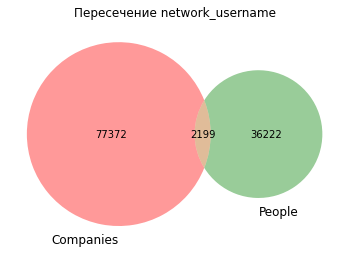

In [28]:
#Диаграмма Венна
plt.figure(figsize=(6,6))
venn2([company_usernames, people_usernames], set_labels=('Companies', 'People'))
plt.title('Пересечение network_username')
plt.show()

**Вывод:** данные столбцы имеют практически не пересекающиеся наборы данных, это еще раз доказывает что `network_username` не подходит в качестве столбца для объединения датасетов

### 2.4. Проблемный датасет и причина возникновения пропусков

**Задача:**   

* Привести данные датасета `company_and_rounds` в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратить внимание на структуру датасета, порядок и названия столбцов, проанализировать значения.

* Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовить данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

Объединить company_id_1 и company_id_2

In [29]:
company_and_rounds_df['company_id'] = company_and_rounds_df[['company_id_2', 'company_id_1']].bfill(axis=1).iloc[:,0]
company_and_rounds_df['company_id'] = company_and_rounds_df['company_id'].astype('Int64')

Главная причина большого % пропусков — в одной таблице смешаны факты о компании и строки по раундам  
Одно из решений: разделить на 2 связные таблицы

In [30]:
company_cols = ['company_id', 'name', 'category_code', 'status',
                'founded_at', 'closed_at', 'domain', 'network_username',
                'country_code', 'investment_rounds', 'funding_rounds',
                'funding_total', 'milestones']

companies = (company_and_rounds_df[company_cols]
             .drop_duplicates(subset=['company_id'])
             .reset_index(drop=True))

round_cols = ['funding_round_id', 'company_id', 'funded_at',
              'funding_round_type', 'raised_amount', 'pre_money_valuation',
              'participants', 'is_first_round', 'is_last_round']

rounds = (company_and_rounds_df[round_cols]
          .dropna(subset=['funding_round_id']) 
          .copy())

In [31]:
# число пропусков
missing_count = companies.isna().sum()

# доля пропусков
missing_percent = companies.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

                   missing_count  missing_percent
company_id                     0         0.000000
name                         232         0.001179
category_code              73599         0.374007
status                       232         0.001179
founded_at                105558         0.536413
closed_at                 194165         0.986686
domain                     70240         0.356938
network_username          116194         0.590462
country_code              108795         0.552862
investment_rounds            232         0.001179
funding_rounds               232         0.001179
funding_total                232         0.001179
milestones                   232         0.001179


Пропуски остались в `category_code`, `domain`, `country_code`, `network_username` и `founded_at`: можно оставить как есть. В `closed_at` 98% пропусков — это нормально, значит что компания не закрылась тоже оставляем

In [32]:
# число пропусков
missing_count = rounds.isna().sum()

# доля пропусков
missing_percent = rounds.isna().mean() 
# объединяем в одну таблицу
missing_table = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

print(missing_table)

                     missing_count  missing_percent
funding_round_id                 0         0.000000
company_id                       0         0.000000
funded_at                      248         0.004686
funding_round_type               0         0.000000
raised_amount                    0         0.000000
pre_money_valuation              0         0.000000
participants                     0         0.000000
is_first_round                   0         0.000000
is_last_round                    0         0.000000


В данной таблице можно сказать что пропусков не осталось

Таким образом мы привели данные к виду 2 связанных таблиц, тем самым избавились от пропусков и подготовили данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию.

### Вывод о проделанной работе:

Загрузли данные и провели первичную предобработку:
* Просмотрели данные  
* Привели имена столбцов к единому формату: убрали двойные пробелы, заменили последовательности пробелов на _  
* Привели типы: даты к datetime64[ns] и проанализировали пропуски  
* Создали сводную таблицу по годам на основании столбца `raised_amount` и визуализировали результат  
* Оценили, насколько информация об образовании сотрудников полна. Используя датасеты people.csv и education.csv, разделили все компании на несколько групп по количеству сотрудников и оценили среднюю долю сотрудников без информации об образовании в каждой из групп. А также оценили, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу degrees.csv (Можно)  
* Установили что `network_username` не подходит в качестве столбца для объединения датасетов 
* Нормализовали проблемный company_and_rounds: разделили на две логичные таблицы  

## Шаг 3. Исследовательский анализ объединённых таблиц

> Приступите к шагу 3 после проверки ревьюера.

<big>Студентам нужно чётко сказать - проверять дальше или не проверять.</big>

### 3.1. Объединение данных

Объедините данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы возьмите данные из обработанного датасета `company_and_rounds.csv` — выберите только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. В результирующей таблице должно получиться порядка 40 тысяч компаний.

Проверьте полноту и корректность получившейся таблицы. Далее работайте только с этими данными.

In [33]:
mask = (
    (companies['funding_rounds']   > 0) |
    (companies['investment_rounds']> 0) |
    (companies['status'].eq('acquired'))
)

target_companies = companies.loc[mask].copy()
print('Размер выборки:', len(target_companies))
target_companies.head()

Размер выборки: 40747


,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
1,10,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0
2,100,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0
13,1001,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0
18,10014,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,1.0,0.0,4.0


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

- По предобработанному столбцу `funding_total` графическим способом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.
- В процессе расчёта значений обратите внимание, например, на показатели, возвращаемые методом `.describe()`, — объясните их. Применимы ли к таким данным обычные способы нахождения типичных значений?

In [34]:
x = target_companies['funding_total']
print(x.describe())

summary = x.describe(percentiles=[.5, .9, .95, .99])
summary

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64


count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
50%      6.000000e+05
90%      2.239138e+07
95%      4.350000e+07
99%      1.339487e+08
max      5.700000e+09
Name: funding_total, dtype: float64

In [35]:
Q1, Q3 = x.quantile([.25, .75])
IQR = Q3 - Q1
upper_log = Q3 + 1.5*IQR

print(f'Верхняя граница: {upper_log}')

Верхняя граница: 14126625.0


Можно заметить, что распределение сильно правосторонне скошено.  
count ≈ 40.7 тыс. компаний.  
медиана = 0.6 млн, это гораздо ниже среднего = ~10.1 млн, что указывает на длинный правый хвост.  
std ≈ 56.5 млн >> mean. Очень большая дисперсия.    
Квартильный и перцентильный срез:  
25% = 0 => минимум четверти компаний имеет нулевой funding_total.  
75% ≈ 5.56 млн => основная масса данных лежит в пределах от 0 до ~5.6 млн.  
90% ≈ 22.4 млн, 95% ≈ 43.5 млн, 99% ≈ 134 млн.  
max ≈ 5.7 млрд => присутствуют экстремальные выбросы.

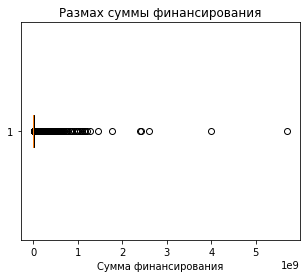

In [36]:
plt.figure(figsize=(5,4))
plt.boxplot(x, vert=False)
plt.title('Размах суммы финансирования')
plt.xlabel('Сумма финансирования')
plt.show()

Boxplot наглядно показывает большое число выбросов 

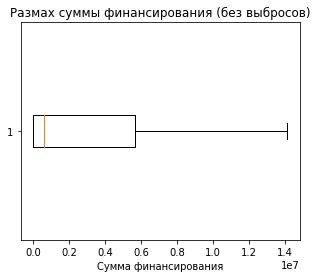

In [37]:
plt.figure(figsize=(5,4))
plt.boxplot(x, vert=False, showfliers=False)
plt.title('Размах суммы финансирования (без выбросов)')
plt.xlabel('Сумма финансирования')
plt.show()

Графики подтверждают длинный правый хвост и наличие множества крупных значений.
Типичным можно считать диапазон — 0.6–5.6 млн (медиана)
По правилу IQR, всё, что выше ~14 млн , можно считать выбросом.
Супер-выбросы — значения сотни миллионов – миллиарды.

Обычные способы нахождения типичных значений, основанные на среднем не подходят для решения:
* Распределение сильно правосторонне скошено;  
* Четверть данных - это нули или пропуски; 
* Среднее и стандартное отклонение становятся неустойчивыми и могут ввести в заблуждение.  

### 3.3. Куплены забесплатно?

- Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

In [38]:
cheap_company = acquisition_df[acquisition_df['price_amount'].isin([0, 1])].copy()

cheap_with_funding = cheap_company.merge(
    companies,
    left_on='acquired_company_id', 
    right_on='company_id',
    how='left'
)

cheap_with_funding = cheap_with_funding[cheap_with_funding['funding_total'].fillna(0) > 0].copy()

cheap_with_funding.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
1,14,318,314,cash,0,2006-10-01,314,Reddit,web,acquired,2005-01-01,NaT,reddit.com,reddit,USA,0.0,1.0,100000.0,3.0
12,65,146,698,cash,0,2007-08-01,698,Maya's Mom,web,acquired,NaT,NaT,mayasmom.com,NaN,USA,0.0,1.0,1000000.0,2.0
14,67,156,718,cash,0,2007-08-01,718,Glimpse,ecommerce,acquired,NaT,NaT,glimpse.com,NaN,USA,0.0,1.0,4000000.0,0.0
16,87,1035,175,cash,0,2007-10-01,175,Newsvine,web,acquired,2005-03-31,NaT,newsvine.com,NaN,USA,0.0,1.0,1250000.0,0.0
20,115,396,1582,cash,0,2007-12-01,1582,BeliefNet,web,acquired,2008-01-01,NaT,beliefnet.com,eliefnet,USA,0.0,1.0,7000000.0,3.0


In [39]:
cheap_with_funding.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1618 entries, 1 to 6926
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    1618 non-null   int64         
 1   acquiring_company_id  1618 non-null   int64         
 2   acquired_company_id   1618 non-null   int64         
 3   term_code             121 non-null    object        
 4   price_amount          1618 non-null   int64         
 5   acquired_at           1614 non-null   datetime64[ns]
 6   company_id            1618 non-null   Int64         
 7   name                  1618 non-null   object        
 8   category_code         1553 non-null   object        
 9   status                1618 non-null   object        
 10  founded_at            1285 non-null   datetime64[ns]
 11  closed_at             13 non-null     datetime64[ns]
 12  domain                1546 non-null   object        
 13  network_username  

In [40]:
cheap_with_funding.describe()

,id,acquiring_company_id,acquired_company_id,price_amount,company_id,investment_rounds,funding_rounds,funding_total,milestones
count,1618.000000,1618.000000,1618.000000,1618.0,1618.000000,1618.000000,1618.000000,1.618000e+03,1618.000000
mean,6303.868974,46063.280593,39632.810878,0.0,39632.810878,0.008035,1.890606,1.815296e+07,1.457973
std,2980.141889,68220.704291,44615.509008,0.0,44615.509008,0.118993,1.243322,1.445030e+08,1.226295
min,14.000000,5.000000,9.000000,0.0,9.000000,0.000000,1.000000,3.750000e+03,0.000000
25%,3912.250000,2720.250000,10491.750000,0.0,10491.750000,0.000000,1.000000,2.000000e+06,0.000000
50%,6799.000000,18183.500000,27868.500000,0.0,27868.500000,0.000000,1.000000,6.000000e+06,1.000000
75%,8842.250000,52739.750000,49818.750000,0.0,49818.750000,0.000000,2.000000,1.550000e+07,2.000000
max,10513.000000,284510.000000,268806.000000,0.0,268806.000000,3.000000,12.000000,5.700000e+09,6.000000


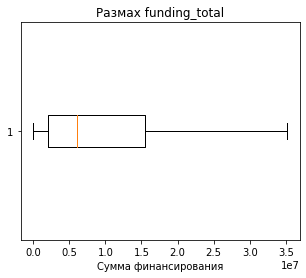

In [41]:
plt.figure(figsize=(5,4))
plt.boxplot(cheap_with_funding['funding_total'], vert=False, showfliers=False)
plt.title('Размах funding_total')
plt.xlabel('Cумма финансирования')
plt.show()

In [42]:
cheap_with_funding['funding_total'].describe()

count    1.618000e+03
mean     1.815296e+07
std      1.445030e+08
min      3.750000e+03
25%      2.000000e+06
50%      6.000000e+06
75%      1.550000e+07
max      5.700000e+09
Name: funding_total, dtype: float64

In [43]:
Q1, Q3 = cheap_with_funding['funding_total'].quantile([.25, .75])
IQR = Q3 - Q1
upper_log = Q3 + 1.5*IQR
lower_log = Q1 - 1.5*IQR
print(f'Верхняя граница: {upper_log}')
print(f'Нижняя граница: {lower_log}')

Верхняя граница: 35750000.0
Нижняя граница: -18250000.0


Нижняя граница получилась отрицательной, это связано с сильными выбросами в данных. В данном случае нижнюю границу можно заменить на 0 т.к сумма финансирования не может быть отрицательной

In [44]:
cheap_with_funding['funding_total'].quantile([.91, .95, .99])

0.91     35894000.0
0.95     51487500.0
0.99    151552930.0
Name: funding_total, dtype: float64

Можно заметить что верхняя граница(Q3) соответствует 91 процентилю 

### 3.4. Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

In [45]:
filtered_acquisition_df = acquisition_df[acquisition_df['price_amount']!=0]

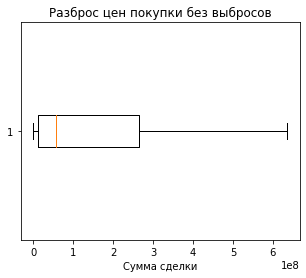

In [46]:
plt.figure(figsize=(5,4))
plt.boxplot(filtered_acquisition_df['price_amount'], vert=False, showfliers=False)
plt.title('Разброс цен покупки без выбросов')
plt.xlabel('Сумма сделки')
plt.show()

Будем считать, что типично высокие цены — это медиана по категории

In [47]:
df = filtered_acquisition_df.merge(
    companies, left_on='acquired_company_id', right_on='company_id', how='left')

In [48]:
median_price_by_cat = (df.groupby('category_code')['price_amount']
      .median()
      .sort_values(ascending=False)
      .rename('median_price'))

top_10_median_cats = median_price_by_cat.head(10)

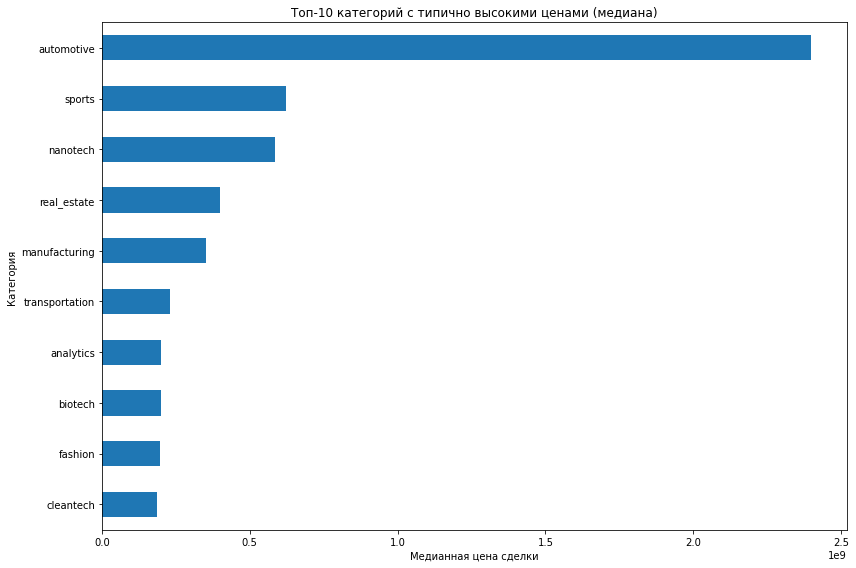

In [49]:
plt.figure(figsize=(12, 8))
(top_10_median_cats.sort_values()
    .plot(kind='barh'))
plt.title('Топ-10 категорий с типично высокими ценами (медиана)')
plt.xlabel('Медианная цена сделки')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

In [50]:
price_q90 = df['price_amount'].quantile(0.9)
df_trim = df[df['price_amount'] <= price_q90].copy()

std_price_by_cat = (df_trim.groupby('category_code', dropna=False)['price_amount']
           .std(ddof=1)           
           .sort_values(ascending=False)
           .rename('std_price'))

top_10_std_cats = std_price_by_cat.head(10)

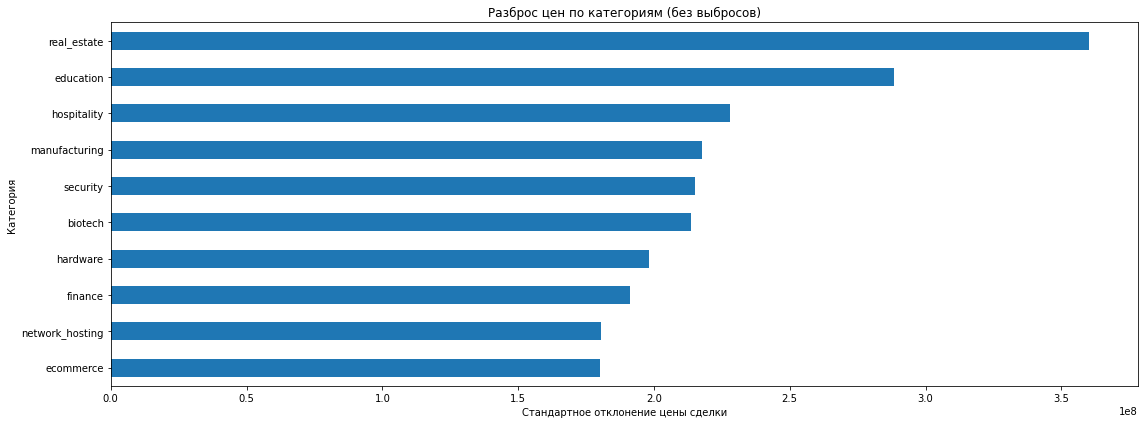

In [51]:
plt.figure(figsize=(16, 6))
top_10_std_cats.sort_values().plot(kind='barh')
plt.title('Разброс цен по категориям (без выбросов)')
plt.xlabel('Стандартное отклонение цены сделки')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

In [52]:
median_price_by_cat = (
    df.groupby('category_code')['price_amount']
      .median()
      .rename('median_price')
)

std_price_by_cat = (
    df_trim.groupby('category_code', dropna=False)['price_amount']
           .std(ddof=1)
           .rename('std_price')
)
count_by_cat = (
    df.groupby('category_code')['price_amount']
      .size()
      .rename('n_deals')
)

scatter_df = (
    pd.concat([median_price_by_cat, std_price_by_cat, count_by_cat], axis=1)
      .dropna(subset=['median_price', 'std_price'])
      .sort_values('median_price', ascending=False)
)

min_deals = 5
scatter_df = scatter_df[scatter_df['n_deals'] >= min_deals]

sizes = (scatter_df['n_deals'] / scatter_df['n_deals'].max()) * 1500 + 80

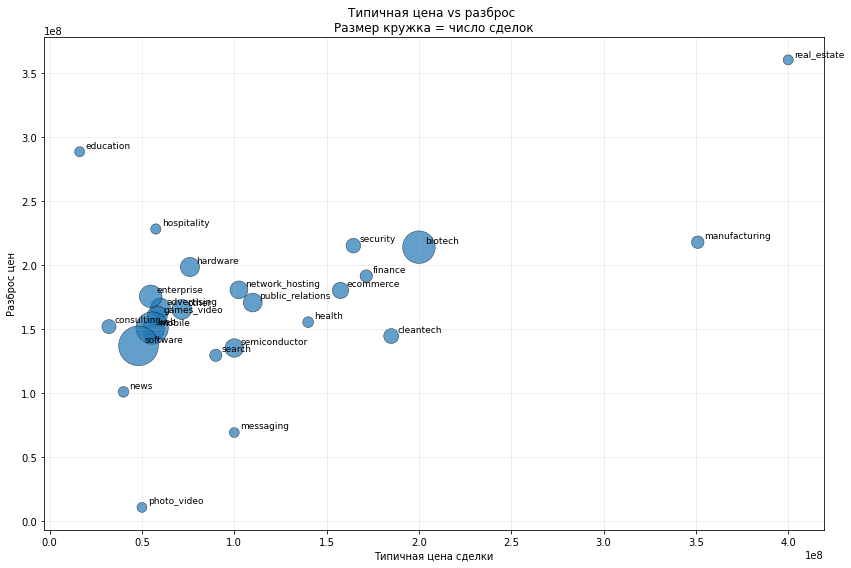

In [53]:
plt.figure(figsize=(12, 8))
plt.scatter(
    scatter_df['median_price'],
    scatter_df['std_price'],
    s=sizes,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5,
)

# подписи
for cat, row in scatter_df.iterrows():
    plt.annotate(
        str(cat),
        (row['median_price'], row['std_price']),
        textcoords='offset points',
        xytext=(6, 4),
        fontsize=9
    )

plt.title('Типичная цена vs разброс \nРазмер кружка = число сделок')
plt.xlabel('Типичная цена сделки')
plt.ylabel('Разброс цен')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Заметим что типично высокие цены:
real_estate (лидер), manufacturing, biotech, затем группа с чуть меньшей медианой — finance, ecommerce, security

Проанализируем наибольший разброс цен:
Также real_estate (лидер), education, manufacturing, biotech, security, hospitality, далее hardware, finance, ecommerce

Категории с одновременными высокими медианами и большим разбросом:
real_estate, manufacturing, biotech, security, finance, ecommerce.

### 3.5. Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

In [54]:
df = target_companies[target_companies['funding_rounds']>0]

In [55]:
stats = (df.groupby('status', dropna=False)['funding_rounds'].agg(count='count', mean='mean', median='median',).sort_values('median', ascending=False))
stats

,count,mean,median
status,,,
ipo,490,2.526531,2.0
acquired,2593,1.896645,1.0
closed,2089,1.383437,1.0
operating,26535,1.642359,1.0


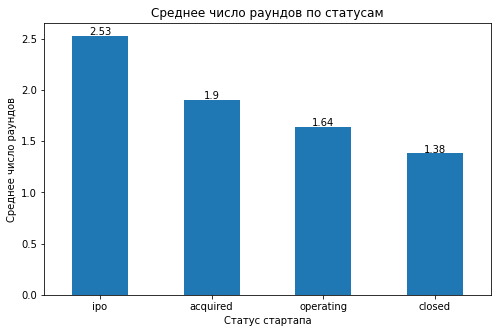

In [56]:
means = (df.groupby('status')['funding_rounds'].mean().sort_values(ascending=False))

ax = means.plot(kind='bar', figsize=(8,5), rot=0, ylabel='Среднее число раундов')
ax.set_xlabel('Статус стартапа')

for i, v in enumerate(means): 
    v = round(v,2)
    plt.text(i,  v + 0.01 ,  str(v), ha='center')

plt.title('Среднее число раундов по статусам')
plt.ylabel('Среднее число раундов')
plt.show()

**ipo** имеет наибольший показатель ≈ 2.53 — в среднем компании доходят до публичного размещения, пройдя наибольшее число раундов.  
**closed** имеет наименьший показатель ≈ 1.38 — закрывшиеся стартапы чаще успевают привлечь мало (один-два раунда)


## Шаг 4. Итоговый вывод и рекомендации

Опишите, что было сделано в проекте, какие были сделаны выводы, подкрепляют ли они друг друга или заставляют сомневаться в полученных результатах.

### Итоги о проделанной работе

**Загрузка и первичный осмотр данных** 
* Загрузили 5 датасетов (acquisition, company_and_rounds, education, people, degrees).
* Просмотрели данные  
* Привели имена столбцов к единому формату: убрали двойные пробелы, заменили последовательности пробелов на _  
* Привели типы: даты к datetime64[ns] и проанализировали пропуски  
* Создали сводную таблицу по годам на основании столбца `raised_amount` и визуализировали результат  
* Оценили, насколько информация об образовании сотрудников полна. Используя датасеты people.csv и education.csv, разделили все компании на несколько групп по количеству сотрудников и оценили среднюю долю сотрудников без информации об образовании в каждой из групп. А также оценили, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу degrees.csv (Можно)  
* Установили что `network_username` не подходит в качестве столбца для объединения датасетов 
* Нормализовали проблемный company_and_rounds: разделили на две логичные таблицы   

**Исследовательский анализ объединенных таблиц**  
* Отобраны компании с признаком инвестдеятельности или статусом acquired ≈40 747 компаний (соответствует ожиданиям по ТЗ).  
* Проведена описательная статистика: медиана ≈ 0.6(млн.), p90 ≈ 22.4(млн.), p95 ≈ 43.5(млн.), p99 ≈ 133.9(млн.); сильная правосторонняя асимметрия. По правилу IQR верхняя граница “типичных” значений порядка ~14 (млн.), всё выше — выбросы.  
* Найдены сделки с price_amount ∈ {0,1} и при этом у цели funding_total > 0  
* Выделен топ категорий с “типично высокими” ценами (верхний квартиль price_amount): перечислены biotech, software, web, enterprise, advertising, public_relations. Посчитан топ-10 категорий с наибольшим размахом цен. Пересечение двух топов дало 3 общих категории: enterprise, public_relations, software.
* Сравнена funding_rounds по статусам

Что подкрепляет полученные резуьтаты:  
1) Пересечение топов категорий по цене и по разбросу (enterprise, public_relations, software)  
2) Деление company_and_rounds на companies/rounds, что позволило избежать путаницы с пропусками и корректная дальнейшая агрегация.

**Рекомендации:**  
Для стратегий, нацеленных на максимально высокий чек, ориентироваться стоит на  `real_estate`, `manufacturing`, `biotech` категории; для сбалансированного профиля "доходность/риск" —  `finance`, `ecommerce`, `security`